In [1]:
# Esame 654AA - a.a. 2025/2026
# Studenti: Leonardo Celati, Samuele Taviano
# Matricole: 660185, ?

In [2]:
from sklearn.preprocessing import StandardScaler

import cup_common as cc
import nn_common as nnc
import cross_common as cr
import torch
import torch.nn as nn
import importlib
from functools import partial
import pandas as pd
import copy
import svm_common as sc

importlib.reload(nnc)
importlib.reload(cc)
importlib.reload(cr)

<module 'cross_common' from '/Users/leonardo/workspace/library/source/it.unipi.654AA/notebooks/cross_common.py'>

<h3>Preparation</h3>
<hr/>

<h4>Data preparation</h4>
<p>The train and test dataset are loaded in form of Pandas DataFrame for better interaction with PyTorch.
Eventually there will be these objects:
<ul>
<li>X_tr, y_tr: the train features and train labels (or classes)</li>
<li>X_ts, y_ts: the test features and test labels (or classes)</li>
</ul>
</p>

In [3]:
importlib.reload(cr)
df_train, df_test = cc.load_set()

# Scaler
scaler = StandardScaler()
# The train set used for model selection
# and final testing
X_tr, y_tr = cc.prepare_dataset(df_train)
X_ts, y_ts = cc.prepare_dataset(df_test)

# Important!!!! The following dataset is prepared for investigation purpose and dry run of the NN pipeline,
# in order to check for correctness of function calls and graphics plot
# it is absolutely not meant to be used for model selection
dry_run_scaler = StandardScaler()
X_tr_dry_run, y_tr_dry_run, X_ts_dry_run, y_ts_dry_run = cc.prepare_dataset_for_dry_run(df_train, ratio=0.2, scaler=dry_run_scaler)

features_names = X_tr.columns
cr.dataset_introspection(df_train, df_test)

,Property,Training,Test
0,Number of samples,500,1000
1,Number of features,15,11
2,Class values,[],[]
3,Class balance,[],[]


<h4>Network Architecture</h4>
<p>Defining and selecting a hypothesis space with hyper-parameter around a neural network architecture:
<ul>
<li><b>net</b>: represent the internal NN structure with input, hidden and output layer.
One important thing to consider is that the output layer <u>must be kept linear</u> in order to be able to
plug the loss function and the output adapter</li>
<li><b>output_adapter</b>: the function which takes the output from the NN and apply the latest trasformation (classification, regression, etc...).
Must be coherent with the optimizer_template. See function docs for details</li>
<li><b>model_template</b>: the model itself, a skeleton which holds the net structure, and the output adapter function.
The model is always cloned troughout the notebok, just to keep a template reference.</li>
<li><b>optimizer_template</b>: the weight update algorithm</li>
<li><b>scheduler_template</b>: implements adaptive learning rate decay by using ReduceLROnPlateau together with the optimizer template</li>
</ul>
</p>

In [4]:
# Set to True when model is selcted and assessed
dump_prediction = False

# The seed to be used by data splitter
default_state = 42
default_seed = 1

# Starting learning rate
learning_rate = 1e-3

# The input dimension (i.e. the input layer) is obviously
# the number of feature of the TR set
input_dimension = X_tr.shape[1]


# Defining network architecture
# For simplicity we start with just one hidden layer with small nr of hidden unit
hidden_unit = 64
net = nn.Sequential(
    # 1st Hidden Layer
    nn.Linear(input_dimension, 128, bias=True), # <- NET
    nn.ReLU(), # <- Activation function
    #nn.Tanh(), # <- Activation function

    nn.Linear(128, 64, bias=True), # <- NET
    nn.ReLU(), # <- Activation function
    #nn.Tanh(), # <- Activation function

    # Output layer
    # The output layer is kept linear in order to decouple
    # the network architecture from the choice of the loss function
    # and the prediction phase
    nn.Linear(64, 4, bias=True) # <- NET
)

# The output and loss function, must be changed according to the type of task
loss_function = nnc.MEELoss() #nn.MSELoss()
output_adapter = nnc.regression_adapter()

# Model implementation
model_template = nnc.MLP(net, output_adapter)
# weights initialization (for academic purposes)
model_template.apply(lambda m: nnc.init_weights(m, method="kaiming", nonlinearity="relu"))

# The weight update algorithm
optimizer_template = partial(
    torch.optim.AdamW,
    lr=1e-3,
    weight_decay=1e-4
)

# The factor by learning rate will decrease
learning_rate_decay_factor = 0.5
# The epoch to wait before applying the rate decay factor
learning_rate_decay_patience = 10
# The threshold for measuring the new optimum
learning_rate_decay_threshold = 1e-4

# The learning rate decay function
scheduler_template = partial(
    torch.optim.lr_scheduler.ReduceLROnPlateau,
    mode="min", factor=learning_rate_decay_factor, patience=learning_rate_decay_patience,
    threshold=learning_rate_decay_threshold
)

print(model_template)

MLP(
  (_net): Sequential(
    (0): Linear(in_features=12, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=4, bias=True)
  )
)


In [5]:
importlib.reload(nnc)
print(loss_function)

MEELoss(reduction='mean') - custom function


<h3>NN Run</h3>
<p>The NN run is separated in two distinct scenarios independent from each other:
<ol>
<li>Hold-out: meant ot be used for inspecting the correctness of the whole pipeline (i.e. no error, effectiveness of learning rate decay, plotting etc...).</li>
<li>KFold: meant to be used for model selection and asessment eventually leading to testing evaluation.</li>
</ol>
</p>
<hr/>

<h4>Hold-out</h4>
<p>Hold-out validation is used for preliminary inspection of learning dynamics, and performed trough a specific dry run set elaborated from the original train set, whereas final model selection based on K-Fold cross-validation.</p>

<h5>Training</h5>
<p>Training the model.</p>

In [6]:
importlib.reload(nnc)

# custom settings
# Either batch, online or the mini-batch size
ho_batch_size="batch"
ho_epochs=300
# Enabling Early stopping
ho_patience = 50 # patience <0 will disable early stopping
ho_min_delta = 1e-4 # ignored if early stopping disabled

# Clone an untrained model and its optimizer
model_dry_run = copy.deepcopy(model_template)

dry_run_result = nnc.train(
    model_dry_run, nnc.SplitByRatioAndSeedStrategy(X_tr_dry_run, y_tr_dry_run, seed=default_seed), optimizer_template, loss_function,
    batch_size=ho_batch_size, epochs=ho_epochs,
    early_stopping_strategy=nnc.EarlyStoppingStrategy(patience=ho_patience, min_delta=ho_min_delta),
    scheduler_template=scheduler_template
)

Early stopping at epoch 202 (best VL loss: 164.4780)
Train summary
----------------------------------------------------------------------------------------------------
Epochs          | 300
Train           | samples: 320
Validation      | samples: 80
Batch type      | batch
Loss function   | MEELoss(reduction='mean') - custom function
Optimizer       | class: <class 'torch.optim.adamw.AdamW'> , params: {'lr': 0.001, 'weight_decay': 0.0001}
LR Decay        | params: {'mode': 'min', 'factor': 0.5, 'patience': 10, 'threshold': 0.0001}
Early Stopping  | patience: 50 , minimum delta: 0.0001
----------------------------------------------------------------------------------------------------


In [7]:
epochs_tr = dry_run_result.epochs_tr_mse
epochs_vl = dry_run_result.epochs_vl_mse
epochs_tr_mee = dry_run_result.epochs_tr_mee
epochs_vl_mee = dry_run_result.epochs_vl_mee
epochs_grad = dry_run_result.epochs_grad

<h5>Gradient Norm</h5>
<p>The gradient norm should gradually decrease throughout epochs, indicating that the optimization process moves toward a stable region of the loss landscape.</p>

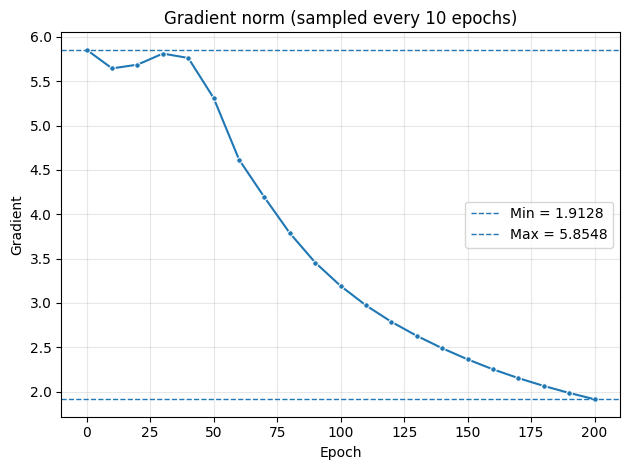

In [8]:
importlib.reload(nnc)
nnc.plot_gradient_norm_line(epochs_grad, step=10)

<h5>Epoch Loss</h5>

<Figure size 640x480 with 0 Axes>

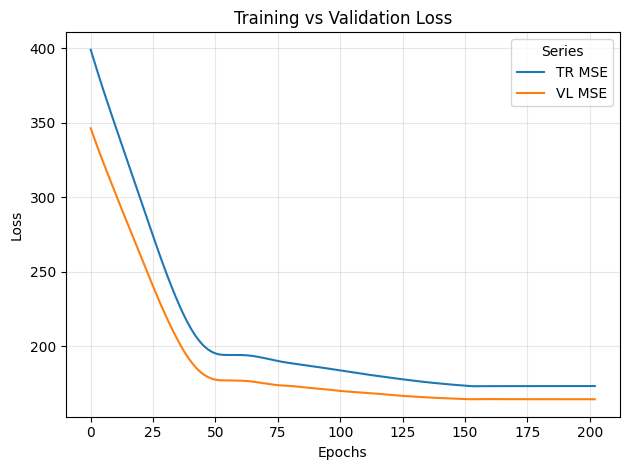

In [9]:
nnc.plot_epoch_loss(epochs_tr, epochs_vl)

In [10]:
print("min MEE: {} - best epoch: {}".format(dry_run_result.min_vl_mee, dry_run_result.best_mee_epoch))


min MEE: 22.536907196044922 - best epoch: 153


<h5>Dry Run Prediction</h5>
<p>A final hold-out subset was extracted from the training data and used only for didactic prediction analysis, allowing qualitative inspection of the model outputs. <u>This step is not impacting the model selection and did not influence any design or selection decision</u>.</p>

In [11]:
all_pred_dry_run = nnc.predict(model_dry_run, X_ts_dry_run)

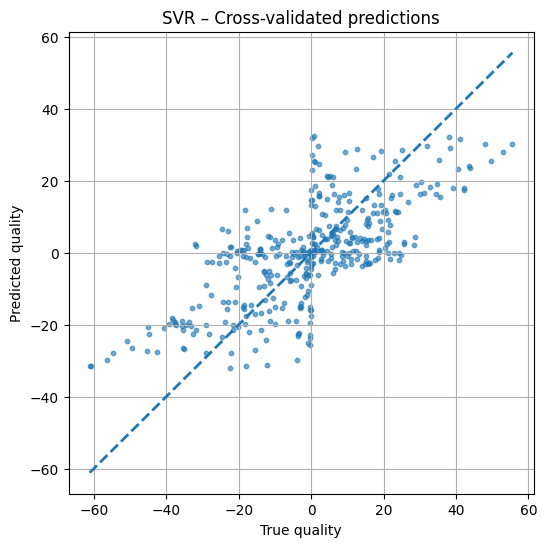

In [12]:
y_pred_dry_run = pd.DataFrame(all_pred_dry_run[0].detach().cpu().numpy())
sc.plot_true_vs_preds_svr(y_ts_dry_run, y_pred_dry_run)

<hr/>

<h4>KFold</h4>
<p>Model selection is performed using K-Fold cross-validation on the training data, while an initial hold-out split was used only for preliminary analysis and debugging.</p>

<h5>Run</h5>

In [13]:
#nnc.train_wrapper_fn(model_template,nnc.ManualSplitStrategy(X_tr, y_tr, X_vl, y_vl))
# runner = cc.TorchNNRunner(model_template, nnc.train())

In [15]:
importlib.reload(nnc)
importlib.reload(cc)

# The KFold strategy to be used trough all models
fold_strategy = cr.common_fold_strategy()

# Epochs
kv_epochs=500
#kv_batch_size=64
kv_batch_size="batch"

inner_train_params = {
    "epochs": kv_epochs,
    "batch_size": kv_batch_size,
    "scheduler_template": scheduler_template,
    "optimizer_template": optimizer_template,
    "loss_function": loss_function,
}

fold_histories = nnc.kfold(
    model_template, X_tr, y_tr, fold_strategy, inner_train_params, scaler
)


  
Perform fold: 0, train size: 400, val size: 100
Train summary
----------------------------------------------------------------------------------------------------
Epochs          | 500
Train           | samples: 400
Validation      | samples: 100
Batch type      | batch
Loss function   | MEELoss(reduction='mean') - custom function
Optimizer       | class: <class 'torch.optim.adamw.AdamW'> , params: {'lr': 0.001, 'weight_decay': 0.0001}
LR Decay        | params: {'mode': 'min', 'factor': 0.5, 'patience': 10, 'threshold': 0.0001}
Early Stopping  | disabled
----------------------------------------------------------------------------------------------------
  
Perform fold: 1, train size: 400, val size: 100
Train summary
----------------------------------------------------------------------------------------------------
Epochs          | 500
Train           | samples: 400
Validation      | samples: 100
Batch type      | batch
Loss function   | MEELoss(reduction='mean') - custom function

<h5>Metric</h5>
<p>Main metric used for model assessment.
</p>

In [ ]:
importlib.reload(cc)
mean, std = cc.extract_mean_std(fold_histories, "fold_vl_mee")
print(f"{mean:.4f} ± {std:.4f}")

In [ ]:
cr.plot_kfold_mee(fold_histories)

<p>Although the network is trained using a loss aligned with the evaluation metric (MEE), we also report RMSE values for completeness and interpretability but not for model selection, as RMSE is a widely used regression metric and provides insight into per-component prediction errors.</p>

In [ ]:
cr.plot_kfold_rmse(fold_histories)

In [ ]:
cr.plot_kfold_mse(fold_histories)

In [ ]:
cr.plot_kfold_mae(fold_histories)

In [ ]:
cr.kfold_regression_table(fold_histories, use="mee", derive_rmse=True)

<h5>Training</h5>
<p>Model is eventually trained with best parameters verified from KFold, in order to predict on official test set.</p>

In [ ]:
# Prepare and scale datasets
X_tr, y_tr = cc.prepare_dataset(df_train, scaler=scaler, fit_scaler=True)   # fit+transform
X_ts, y_ts = cc.prepare_dataset(df_test,  scaler=scaler, fit_scaler=False)

model_kf = copy.deepcopy(model_template)

train_kf_result = nnc.train(
    model_kf, nnc.SplitByRatioAndSeedStrategy(X_tr, y_tr),
    **inner_train_params
)

In [ ]:
epochs_kf_vl_mee = train_kf_result.epochs_vl_mee
epochs_kf_tr_mee = train_kf_result.epochs_tr_mee
epochs_kf_tr_mse = train_kf_result.epochs_tr_mse
epochs_kf_vl_mse = train_kf_result.epochs_vl_mse
epochs_kf_grad = train_kf_result.epochs_grad

<h5>Gradient Norm</h5>
<p>The gradient norm should gradually decrease throughout epochs, indicating that the optimization process moves toward a stable region of the loss landscape.</p>

In [ ]:
importlib.reload(nnc)
nnc.plot_gradient_norm_line(epochs_kf_grad, step=10)

<h5>Epoch Loss</h5>

In [ ]:
importlib.reload(nnc)
nnc.plot_epoch_mee(epochs_kf_tr_mee, epochs_kf_vl_mee)

In [ ]:
importlib.reload(cc)
mean, std = cr.mean_std_from_kfold(epochs_kf_vl_mee)
print(f"{mean:.4f} ± {std:.4f}")

In [ ]:
#if dump_prediction:
all_pred = nnc.predict(model_kf, X_ts)
print(all_pred)